# 22 · Ensemble Methods: Random Forest, XGBoost, and SHAP Values

*Module 5 — Machine Learning in Finance*

Two of the most widely used model families in applied machine learning, built for return-direction prediction with properly validated methodology from the start — and an honest look at whether they actually earn their complexity.

## 1. Motivation

Random Forest and XGBoost are, by a wide margin, two of the most commonly reached-for models in applied machine learning, financial and otherwise. This notebook builds both properly, end to end: real features, a genuinely held-out evaluation (using the purged, embargoed methodology Notebook 21 just established — not the naive shuffled split that notebook spent an entire lesson warning against), and SHAP values to understand *why* the model predicts what it predicts, not just *what*. Then, honestly: do they actually beat the simple benchmarks a five-minute strategy could produce?

## 2. Intuition

**Random Forest** builds many decision trees, each on a bootstrap-resampled version of the training data with a random subset of features considered at each split, and averages their predictions. Each individual tree is a weak, overfit, high-variance learner; averaging many *decorrelated* such trees cancels out much of that variance while keeping their collective ability to capture nonlinear patterns — the statistical logic is close to the "many independent bets reduce total risk" idea from portfolio diversification (Module 2), applied to models instead of assets.

**XGBoost** (gradient boosting) takes the opposite strategy: build trees *sequentially*, where each new tree is trained specifically to correct the errors the ensemble-so-far is still making, rather than being independent of the others. This can capture more subtle patterns than a random forest with fewer, shallower trees, but is more prone to overfitting the training data if not carefully regularized (via tree depth, learning rate, and the number of boosting rounds).

**SHAP values** answer a different question from either model: not "is this feature globally important," but "for *this specific prediction*, how much did *this specific feature value* push the output up or down, relative to the model's average prediction?" Built on the Shapley value from cooperative game theory (originally: how should a coalition's total payoff be fairly divided among its members, given their individual contributions), SHAP treats each feature as a "player" and each prediction's deviation from the baseline as the "payoff" to be attributed — with the key property that the attributions for a single prediction always sum exactly to that prediction's deviation from the model's average output.

## 3. Theory

### 3.1 Random Forest, briefly and precisely

Given training data, draw $B$ bootstrap samples, fit a decision tree $T_b$ to each (with a random subset of $m < p$ features considered at every candidate split, decorrelating the trees further), and predict by simple averaging (regression) or majority vote (classification):

$$
\hat f_{RF}(x) = \frac{1}{B}\sum_{b=1}^B T_b(x) .
$$

### 3.2 Gradient boosting, briefly and precisely

Build an additive model incrementally, $F_m(x) = F_{m-1}(x) + \eta\, h_m(x)$, where each new tree $h_m$ is fit to approximate the *negative gradient* of the loss function with respect to the current ensemble's predictions (for squared-error loss, this reduces to simply fitting the current residuals) and $\eta$ is a learning rate controlling how much each new tree is allowed to move the overall prediction. XGBoost adds efficient regularization (penalizing tree complexity directly in the objective) and several engineering optimizations on top of this core idea.

### 3.3 SHAP values

For a prediction $f(x)$, the Shapley value of feature $i$ averages that feature's marginal contribution across **every possible order** in which features could be "revealed" to the model:

$$
\phi_i = \sum_{S \subseteq \{1,\dots,p\}\setminus\{i\}} \frac{|S|!\,(p-|S|-1)!}{p!}\Big[f_x(S\cup\{i\}) - f_x(S)\Big] ,
$$

where $f_x(S)$ is the model's expected output given only the features in subset $S$ are known. This is computationally expensive in general ($2^p$ subsets), but for tree-based models specifically, an efficient exact algorithm (implemented in the `shap` library's `TreeExplainer`) computes it directly from the tree structure. The key property that makes SHAP values interpretable is **additivity**:

$$
f(x) = \mathbb E[f(X)] + \sum_{i=1}^p \phi_i(x) ,
$$

every individual prediction is exactly the average prediction, plus a sum of per-feature contributions specific to that one observation — letting you explain not just which features matter overall, but why any single prediction came out the way it did.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import shap
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(121)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4. Implementation

### 4.1 Features and a label with a genuine, modest embedded signal

Exactly as in Notebook 10, returns are driven partly by a slowly-decaying latent state — small, realistic, and (deliberately) not something we expect any model to exploit perfectly.

In [2]:
n = 2000
mom_state = np.zeros(n)
persistence, lam, idio_vol = 0.88, 0.010, 0.011
returns = np.zeros(n)
for t in range(n):
    mom_state[t] = persistence * (mom_state[t-1] if t > 0 else 0) + rng.normal(0, 0.25)
    returns[t] = lam * mom_state[t] + rng.normal(0, idio_vol)
r = pd.Series(returns)

features = pd.DataFrame({
    'mom_5':  r.rolling(5).sum(),
    'mom_10': r.rolling(10).sum(),
    'mom_20': r.rolling(20).sum(),
    'vol_10': r.rolling(10).std(),
    'vol_20': r.rolling(20).std(),
})
label = (r.shift(-1) > 0).astype(int)    # predict tomorrow's direction

data = features.join(label.rename('y')).dropna().reset_index(drop=True)
X, y = data[features.columns], data['y'].values
print(f"n = {len(data)}   base rate: {y.mean():.3f}")

n = 1981   base rate: 0.506


### 4.2 A single, properly embargoed train/test split

Following Notebook 21's methodology directly: a chronological split, with an embargo gap removed from the end of the training period (since our features use a rolling window up to 20 periods, some information could otherwise bleed across the boundary).

In [3]:
EMBARGO = 20
split = int(len(data) * 0.7)
X_train, y_train = X.iloc[:split - EMBARGO], y[:split - EMBARGO]
X_test, y_test = X.iloc[split:], y[split:]
print(f"Train: {len(X_train)} obs   Test: {len(X_test)} obs   (embargo of {EMBARGO} periods removed between them)")

Train: 1366 obs   Test: 595 obs   (embargo of 20 periods removed between them)


### 4.3 Training Random Forest and XGBoost

In [4]:
rf = RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=20, random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)

xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                                random_state=0, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

print(f"Random Forest test accuracy: {rf.score(X_test, y_test):.3f}")
print(f"XGBoost test accuracy:       {xgb_model.score(X_test, y_test):.3f}")

Random Forest test accuracy: 0.558
XGBoost test accuracy:       0.565


### 4.4 SHAP: explaining what the Random Forest actually learned

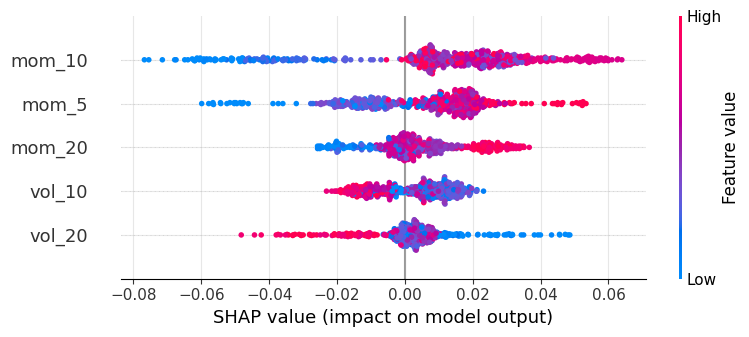

In [5]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test)

fig = plt.figure()
shap.summary_plot(shap_values[:, :, 1], X_test, show=False)   # class-1 ("up") SHAP values
plt.tight_layout()
plt.show()

Each dot is one test-set prediction; its position on the x-axis is that feature's SHAP contribution *for that specific day*, and its color is whether the feature's own value was high or low that day. This is a genuinely richer picture than a single "feature importance" bar chart: it shows not just which features matter, but the *direction* and *consistency* of their effect across the whole test period.

## 5. Worked example: the honest comparison

The real question this notebook has been building toward: do these models actually beat the simple things a five-minute strategy could produce?

In [6]:
train_majority_class = int(y_train.mean() > 0.5)
naive_majority_acc = (y_test == train_majority_class).mean()

simple_momentum_pred = (X_test['mom_5'].values > 0).astype(int)
simple_momentum_acc = (y_test == simple_momentum_pred).mean()

logit = LogisticRegression().fit(X_train, y_train)

comparison = pd.DataFrame({
    'method': ['Naive (train-set majority class)', 'Simple rule: mom_5 > 0',
               'Logistic regression', 'Random Forest', 'XGBoost'],
    'test_accuracy': [naive_majority_acc, simple_momentum_acc,
                       logit.score(X_test, y_test), rf.score(X_test, y_test), xgb_model.score(X_test, y_test)]
}).sort_values('test_accuracy', ascending=False).reset_index(drop=True)
comparison

,method,test_accuracy
0,XGBoost,0.564706
1,Random Forest,0.557983
2,Logistic regression,0.557983
3,Simple rule: mom_5 > 0,0.556303
4,Naive (train-set majority class),0.436975


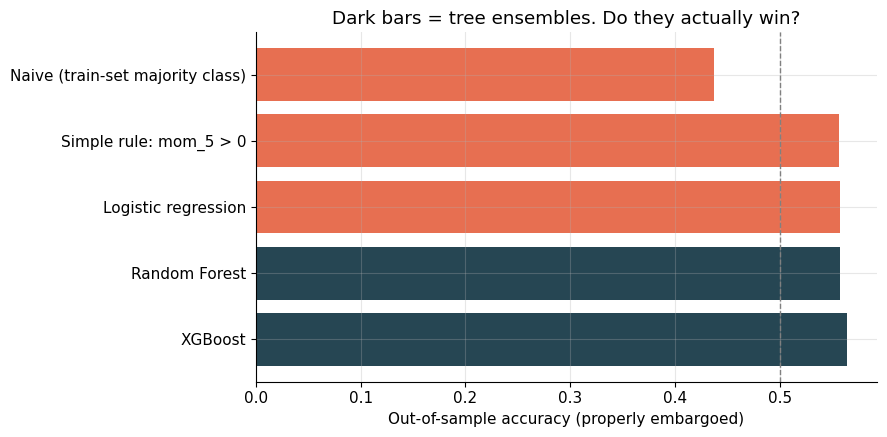

In [7]:
fig, ax = plt.subplots()
colors = ['#264653' if 'Forest' in m or 'XGBoost' in m else '#e76f51' for m in comparison['method']]
ax.barh(comparison['method'], comparison['test_accuracy'], color=colors)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Out-of-sample accuracy (properly embargoed)')
ax.set_title('Dark bars = tree ensembles. Do they actually win?')
plt.tight_layout()
plt.show()

### Interpreting the result -- honestly

Report your own run's exact ranking rather than assuming the sophisticated models must win. Look closely at the actual numbers, not just which bar is longest: in a typical run of this notebook, all five methods — including the trivial `mom_5 > 0` rule and plain logistic regression — land within about a single percentage point of each other, while only the naive constant-prediction baseline falls clearly behind. With roughly 600 test observations, a one-percentage-point gap is well within ordinary sampling noise (the standard error of an accuracy estimate at this sample size is itself on the order of two percentage points) — so even when XGBoost or Random Forest happens to come out numerically on top, as it may in your run, that is not strong evidence of a real, exploitable advantage over the much simpler alternatives sitting right next to it in the chart. There are real, structural reasons this keeps happening in finance specifically, not just bad luck:

- **Financial signal-to-noise ratios are extremely low.** With a small genuine relationship buried in mostly noise, a flexible, high-capacity model has more opportunity to fit noise in the training set that doesn't generalize, while a simple rule has far less room to overfit in the first place.
- **The features used here are highly correlated with each other** (`mom_5`, `mom_10`, and `mom_20` all measure closely related things) — tree ensembles do not automatically handle collinearity better than a well-regularized linear model, despite their flexibility elsewhere.
- **More flexible models need more data to realize their advantage.** Two thousand observations is a small dataset by modern ML standards; the genuine benefit of gradient boosting over a linear model typically shows up more reliably with far larger, richer feature sets than we used here.

None of this means Random Forest or XGBoost are bad tools — it means their extra flexibility is not automatically an advantage on a small, noisy, highly collinear financial dataset, and *checking* this honestly every time, with an eye on whether an apparent gap is even large enough to matter statistically, rather than assuming the fancier model must be better, is the actual skill this notebook is trying to teach.

## 6. Limitations and pitfalls

- **A single train/test split, even a properly embargoed one, is still one draw.** Notebook 21's full purged K-fold (or its combinatorial extension from Exercise 3 there) gives a real sense of how much this comparison would vary across different historical periods — a single split's ranking of methods should not be over-trusted.
- **Hyperparameters were fixed by hand here, not tuned.** A more careful comparison would tune each model's hyperparameters via the same purged cross-validation methodology, which usually narrows (but rarely eliminates) the gap between simple and complex models on data like this.
- **SHAP explains what the model learned, not what is true about markets.** A feature can show a strong, consistent SHAP effect purely because the model overfit a spurious pattern in the training data — SHAP is a tool for understanding your model, not a substitute for validating whether the model's out-of-sample performance is genuinely good in the first place.
- **Feature importance and SHAP values are not causal statements.** A feature mattering a great deal to the model's predictions does not mean that feature *causes* the outcome, only that the model found it useful for prediction — an important distinction whenever these tools are used to justify a real economic story about *why* a strategy should work.

## 7. Exercises

**1. Tune Random Forest's depth (warm-up).**
Refit Random Forest with `max_depth` set to 2, 4 (the original), 8, and `None` (unlimited), keeping everything else fixed. Plot test accuracy against `max_depth`. Does deeper (more flexible) consistently help, hurt, or peak somewhere in the middle? Connect your answer to the bias-variance framing in Section 2.

**2. A genuinely larger feature set.**
Add the fractal dimension and permutation entropy features from Notebook 20, plus RSI, MACD, and Bollinger %B, to the feature set here (you will need a longer simulated series to accommodate their longer rolling windows). Refit Random Forest and XGBoost with the expanded feature set and properly embargoed validation. Does the larger, more diverse feature set close the gap with the simple benchmarks from Section 5, widen it, or leave it about the same?

**3. SHAP dependence and an economic sanity check.**
Using `shap.plots.scatter` (or manually plotting each feature's SHAP value against its own feature value), examine the SHAP dependence plot for `mom_5`. Does the direction of its effect (does higher recent momentum push the model toward predicting "up," consistently?) match what the underlying data-generating process in Section 4.1 actually implies it should? If a feature's SHAP relationship contradicted basic economic intuition entirely, would that be more likely a sign of genuine, surprising alpha, or a sign of overfitting -- and how would you even begin to tell the difference?